In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re
import time


D:\anaconda\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
D:\anaconda\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
url = "https://www.ambitionbox.com/list-of-companies?campaign=desktop_nav"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
    "Accept-Language": "en-US,en;q=0.9"
}


In [3]:
response = requests.get(url, headers=headers)
print(response.status_code)

200


In [4]:
title=[]
rating=[]
c_type=[]
headoffice=[]
operations_spread=[]
job_openings=[]
h_rate=[]
c_rate=[]
reviews=[]

for i in range (1,26):
    url = f"https://www.ambitionbox.com/list-of-companies?campaign=desktop_nav&page={i}"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
        "Accept-Language": "en-US,en;q=0.9"
            }

    page = requests.get(url, headers=headers)
    soup = BeautifulSoup(page.text,"html.parser")
    

    #Titles
    for i in soup.find_all("a",class_="companyCardWrapper__companyName"):
        title.append(i.text.strip())
        
    #Ratings
    for i in soup.find_all("div", class_="rating_star_container"):
        text = i.text.strip()
        if text:
            rating.append(text)
        

    # c_type
    for i in soup.find_all("span", class_="companyCardWrapper__interLinking"):  
        text = i.text.strip()
        typ = re.findall(r"(\w.+)\|", text)
        if typ:
            c_type.append(typ[0])
        else:
            c_type.append(np.nan)

    # Head office
    for i in soup.find_all("span", class_="companyCardWrapper__interLinking"):
        text = i.text.strip()
        loc=re.findall(r"(?:\|\s*|^)([A-Za-z\s]+?)(?:\s*/|\s*\+|$)",text) 
        if loc:
            headoffice.append(loc[0])

    # operations_spread
    for i in soup.find_all("span", class_="companyCardWrapper__interLinking"):
        text = i.text.strip()
        loc=re.findall(r"\+(\d+)\s+other\s+locations",text) 
        if loc:
            operations_spread.append(int(loc[0])+1)
        else:
            operations_spread.append(np.nan)

                
    # No of job openings
    for i in soup.find_all("a",class_="companyCardWrapper__ActionWrapper"):
        text=i.text.strip()
        job = re.findall(r"(\S+)\sJobs",text)
        if job:
            job_openings.append(job[0])

    # Highly Rated & Critically rated
    rating_blocks = soup.find_all("div", class_="companyCardWrapper__ratingComparisonWrapper")
    titles_on_page = soup.find_all("a", class_="companyCardWrapper__companyName")
    
    for i in range(len(titles_on_page)):
        if i < len(rating_blocks):
            text = rating_blocks[i].text.strip()
    
            match_high = re.search(r"Highly Rated For (.*?)(?:Critically Rated For|$)", text)
            h_rate.append(match_high.group(1).strip() if match_high else np.nan)
    
            match_crit = re.search(r"Critically Rated For (.*)", text)
            c_rate.append(match_crit.group(1).strip() if match_crit else np.nan)
        else:
            h_rate.append(np.nan)
            c_rate.append(np.nan)


    #Reviews
    for i in soup.find_all("span",class_="companyCardWrapper__companyRatingCount"):  
            text = i.text.strip()
            rev = re.findall(r"\b\d+(?:\.\d+)?k?\b",text) 
            if rev:
                reviews.append(rev[0])
            else:
                reviews.append(np.nan)

In [5]:
print(f"Titles: {len(title)}")
print(f"Ratings: {len(rating)}")
print(f"Company Type: {len(c_type)}")
print(f"Headoffice: {len(headoffice)}")
print(f"Operations Spread: {len(operations_spread)}")
print(f"Job Openings: {len(job_openings)}")
print(f"Highly Rated: {len(h_rate)}")
print(f"Critically Rated: {len(c_rate)}")
print(f"Reviews: {len(reviews)}")

Titles: 500
Ratings: 500
Company Type: 500
Headoffice: 500
Operations Spread: 500
Job Openings: 500
Highly Rated: 500
Critically Rated: 500
Reviews: 500


In [6]:
import pandas as pd

df = pd.DataFrame({
    "Company Name": title,
    "Industry Type": c_type,
    "Primary Office Location": headoffice,
    "Operating Locations": operations_spread,
    "Job Openings": job_openings,
    "Total Reviews": reviews,
    "Overall Rating": rating,
    "Highly Rated": h_rate,
    "Critically Rated": c_rate
})


In [7]:
df.head(5)

,Company Name,Industry Type,Primary Office Location,Operating Locations,Job Openings,Total Reviews,Overall Rating,Highly Rated,Critically Rated
0,TCS,IT Services & Consulting,Bangalore,433,685,1,3.4,Job Security,"Promotions / Appraisal, Salary & Benefits, Wor..."
1,Accenture,IT Services & Consulting,Bangalore,246,22.7k,68.1k,3.7,NaN,"Promotions / Appraisal, Salary & Benefits, Wor..."
2,Wipro,IT Services & Consulting,Hyderabad,368,4.6k,61k,3.7,Job Security,"Promotions / Appraisal, Salary & Benefits, Wor..."
3,Cognizant,IT Services & Consulting,Hyderabad,226,583,57.9k,3.7,NaN,"Promotions / Appraisal, Salary & Benefits, Wor..."
4,Capgemini,IT Services & Consulting,Bangalore,181,1.7k,49.6k,3.7,"Work Life Balance, Job Security","Promotions / Appraisal, Salary & Benefits, Wor..."


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Company Name             500 non-null    object
 1   Industry Type            495 non-null    object
 2   Primary Office Location  500 non-null    object
 3   Operating Locations      500 non-null    int64 
 4   Job Openings             500 non-null    object
 5   Total Reviews            500 non-null    object
 6   Overall Rating           500 non-null    object
 7   Highly Rated             346 non-null    object
 8   Critically Rated         403 non-null    object
dtypes: int64(1), object(8)
memory usage: 35.3+ KB


In [9]:
df["Job Security"] = np.select(
    [df["Highly Rated"].str.contains("Job Security", na=False),
        df["Critically Rated"].str.contains("Job Security", na=False)],
    ["High","Low" ],
    default="Medium"  
)

In [10]:
df["Work Life Balance"] = np.select(
    [df["Highly Rated"].str.contains("Work Life Balance", na=False),
        df["Critically Rated"].str.contains("Work Life Balance", na=False)],
    ["High","Low"],
    default="Medium" 
)

In [11]:
df["Work Satisfaction"] = np.select(
    [df["Highly Rated"].str.contains("Work Satisfaction", na=False),
        df["Critically Rated"].str.contains("Work Satisfaction", na=False)],
    ["High","Low"],
    default="Medium"
)

In [12]:
df["Promotions"] = np.select(
    [df["Highly Rated"].str.contains("Promotions", na=False),
        df["Critically Rated"].str.contains("Promotions", na=False)],
    ["High","Low"],
    default="Medium"  
)

In [13]:
df = df.drop(columns=["Highly Rated", "Critically Rated"])

In [14]:
def clean_column(col):
    col = col.astype(str).replace('--', '0')
    col = col.replace('nan', '0')  
    return col.apply(lambda x: float(x.replace('k', '')) * 1000 if 'k' in x else float(x))

df['Job Openings'] = clean_column(df['Job Openings']).fillna(0).astype(int)
df['Total Reviews'] = clean_column(df['Total Reviews']).fillna(0).astype(int)

In [15]:
df['Industry Type'] = df['Industry Type'].astype(str).str.strip().replace('nan', 'Other') 

In [16]:
df['Overall Rating'] = df['Overall Rating'].astype(float)

In [17]:
df[['Industry Type','Primary Office Location', 'Job Security', 'Work Life Balance',	'Work Satisfaction', 'Promotions']] = \
df[['Industry Type','Primary Office Location', 'Job Security', 'Work Life Balance',	'Work Satisfaction', 'Promotions']].astype('category')

In [19]:
ambition = df
ambition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Company Name             500 non-null    object  
 1   Industry Type            500 non-null    category
 2   Primary Office Location  500 non-null    category
 3   Operating Locations      500 non-null    int64   
 4   Job Openings             500 non-null    int32   
 5   Total Reviews            500 non-null    int32   
 6   Overall Rating           500 non-null    float64 
 7   Job Security             500 non-null    category
 8   Work Life Balance        500 non-null    category
 9   Work Satisfaction        500 non-null    category
 10  Promotions               500 non-null    category
dtypes: category(6), float64(1), int32(2), int64(1), object(1)
memory usage: 23.1+ KB


In [20]:
ambition.head(5)

,Company Name,Industry Type,Primary Office Location,Operating Locations,Job Openings,Total Reviews,Overall Rating,Job Security,Work Life Balance,Work Satisfaction,Promotions
0,TCS,IT Services & Consulting,Bangalore,433,685,1,3.4,High,Medium,Low,Low
1,Accenture,IT Services & Consulting,Bangalore,246,22700,68100,3.7,Medium,Medium,Low,Low
2,Wipro,IT Services & Consulting,Hyderabad,368,4600,61000,3.7,High,Medium,Low,Low
3,Cognizant,IT Services & Consulting,Hyderabad,226,583,57900,3.7,Medium,Medium,Low,Low
4,Capgemini,IT Services & Consulting,Bangalore,181,1700,49600,3.7,High,High,Low,Low


In [21]:
ambition.to_csv("ambitionbox_companies.csv", index=False)
print("DataFrame created and saved as 'ambitionbox_companies.csv'")

DataFrame created and saved as 'ambitionbox_companies.csv'


In [22]:
# # Univariate Non Visual Analysis

In [23]:
# all categorical columns
cat = ambition.select_dtypes(include=['category'])

In [24]:
cat.head()

,Industry Type,Primary Office Location,Job Security,Work Life Balance,Work Satisfaction,Promotions
0,IT Services & Consulting,Bangalore,High,Medium,Low,Low
1,IT Services & Consulting,Bangalore,Medium,Medium,Low,Low
2,IT Services & Consulting,Hyderabad,High,Medium,Low,Low
3,IT Services & Consulting,Hyderabad,Medium,Medium,Low,Low
4,IT Services & Consulting,Bangalore,High,High,Low,Low


In [25]:
def analyze_categorical(ambition):
    cat_cols = ambition.select_dtypes(include=['category']).columns
    for col in cat_cols:
        print(f"\n{'*'*10}  Categorical Column: {col}  {'*'*10}")
        print(f"Count: {ambition[col].count()}")
        print(f"Number of Unique Values: {ambition[col].nunique()}")
        print(f"Most Frequent Value (Mode): {ambition[col].mode().iloc[0]} "
              f"({ambition[col].value_counts(normalize=True).iloc[0]*100:.2f}%)")
        print("Top 5 Frequent Values:")
        print(ambition[col].value_counts().head())


In [26]:
analyze_categorical(ambition) 


**********  Categorical Column: Industry Type  **********
Count: 500
Number of Unique Values: 57
Most Frequent Value (Mode): IT Services & Consulting (14.80%)
Top 5 Frequent Values:
Industry Type
IT Services & Consulting    74
Pharma                      30
Banking                     26
Internet                    26
Insurance                   26
Name: count, dtype: int64

**********  Categorical Column: Primary Office Location  **********
Count: 500
Number of Unique Values: 42
Most Frequent Value (Mode): Bangalore (21.80%)
Top 5 Frequent Values:
Primary Office Location
Bangalore    109
Mumbai       103
Pune          56
Chennai       45
Hyderabad     43
Name: count, dtype: int64

**********  Categorical Column: Job Security  **********
Count: 500
Number of Unique Values: 3
Most Frequent Value (Mode): Medium (46.00%)
Top 5 Frequent Values:
Job Security
Medium    230
High      201
Low        69
Name: count, dtype: int64

**********  Categorical Column: Work Life Balance  **********
Co

In [27]:
### Contineous / Numerical columns

In [28]:
num= ambition.select_dtypes(include='number')

In [29]:
num.head()

,Operating Locations,Job Openings,Total Reviews,Overall Rating
0,433,685,1,3.4
1,246,22700,68100,3.7
2,368,4600,61000,3.7
3,226,583,57900,3.7
4,181,1700,49600,3.7


In [30]:
def analyze_numerical(ambition):
    num_cols = ambition.select_dtypes(include='number').columns
    for col in num_cols:
        print(f"\n--- Numerical Column: {col} ---")
        print(f"Count: {ambition[col].count()}")
        print(f"Minimum: {ambition[col].min()}")
        print(f"Maximum: {ambition[col].max()}")
        print(f"Mean: {ambition[col].mean()}")
        print(f"Median: {ambition[col].median()}")
        print(f"Standard Deviation: {ambition[col].std()}")
        print(f"Variance: {ambition[col].var()}")
        print(f"Skewness: {ambition[col].skew()}")
        print(f"Kurtosis: {ambition[col].kurt()}")

In [31]:
analyze_numerical(ambition)


--- Numerical Column: Operating Locations ---
Count: 500
Minimum: 15
Maximum: 1788
Mean: 216.71
Median: 143.0
Standard Deviation: 234.947258610645
Variance: 55200.214328657305
Skewness: 2.8332528633509875
Kurtosis: 11.68426783742279

--- Numerical Column: Job Openings ---
Count: 500
Minimum: 0
Maximum: 22700
Mean: 188.456
Median: 32.0
Standard Deviation: 1086.4363137301623
Variance: 1180343.8637915836
Skewness: 18.237307977025292
Kurtosis: 371.9980425511011

--- Numerical Column: Total Reviews ---
Count: 500
Minimum: 1
Maximum: 68100
Mean: 5406.002
Median: 3100.0
Standard Deviation: 7849.872826024988
Variance: 61620503.384765536
Skewness: 4.676867904953683
Kurtosis: 25.107376440017507

--- Numerical Column: Overall Rating ---
Count: 500
Minimum: 2.7
Maximum: 4.9
Mean: 3.8128
Median: 3.9
Standard Deviation: 0.29754533512207143
Variance: 0.0885332264529058
Skewness: -0.3250348521267414
Kurtosis: 0.930828725387252


In [32]:
## Bivariate Non Visual Analysis

In [33]:
# Numeric–Numeric (Correlation)

In [34]:
num.corr()

,Operating Locations,Job Openings,Total Reviews,Overall Rating
Operating Locations,1.000000,0.032414,0.411553,0.179761
Job Openings,0.032414,1.000000,0.490340,-0.065057
Total Reviews,0.411553,0.490340,1.000000,-0.040779
Overall Rating,0.179761,-0.065057,-0.040779,1.000000


In [35]:
#Cat-Num (groupby, pivot table) 

In [36]:
pd.pivot_table(ambition, index='Industry Type',observed=False, columns='Job Security', values='Overall Rating', aggfunc='mean', fill_value=0).head(5)

Job Security,High,Low,Medium
Industry Type,,,
Accounting & Auditing,0.000000,0.0,3.500000
Agro Chemicals,4.066667,0.0,0.000000
Analytics & KPO,0.000000,0.0,3.800000
Auto Components,3.910000,3.6,3.783333
Automobile,4.030000,3.3,3.962500


In [37]:
## Univariate visual analysis

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib as mpl

print(f"Pandas Version: {pd.__version__}")
print(f"Seaborn Version: {sns.__version__}")
print(f"Matplotlib Version: {mpl.__version__}")

Pandas Version: 2.3.3
Seaborn Version: 0.13.2
Matplotlib Version: 3.5.2


In [40]:
pip install --upgrade pandas seaborn

Note: you may need to restart the kernel to use updated packages.


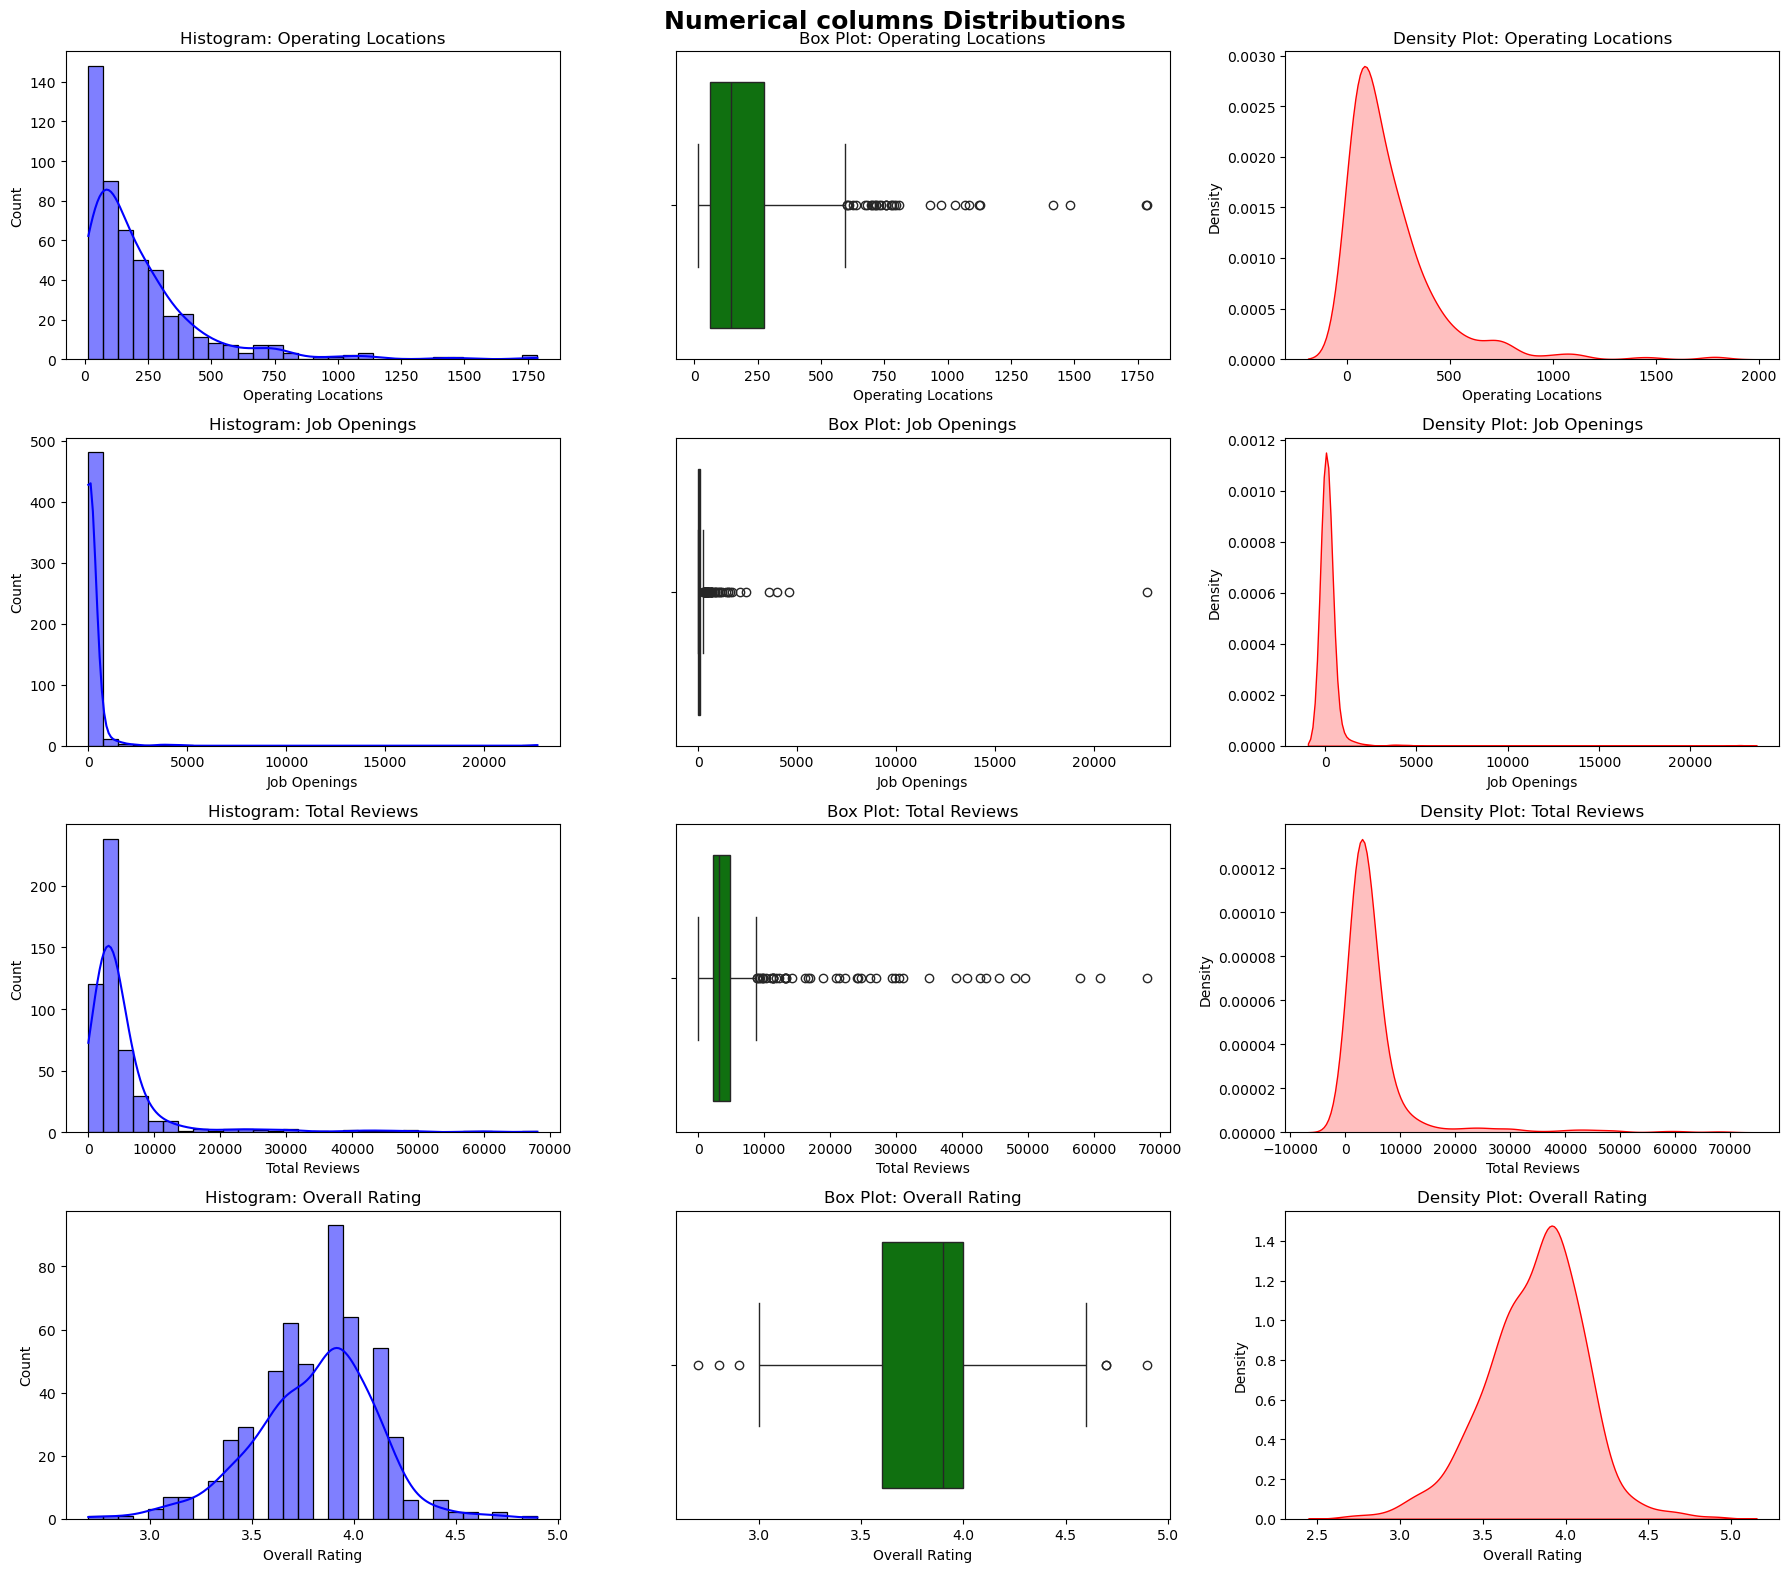

In [41]:
#numeric columns
num_cols = ambition.select_dtypes(include='number').columns
plt.figure(figsize=(18, len(num_cols) * 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 3, 3 * (i - 1) + 1)
    sns.histplot(ambition[col], kde=True, bins=30, color='blue')
    plt.title(f'Histogram: {col}')

    plt.subplot(len(num_cols), 3, 3 * (i - 1) + 2)
    sns.boxplot(x=ambition[col], color='green')
    plt.title(f'Box Plot: {col}')

    plt.subplot(len(num_cols), 3, 3 * (i - 1) + 3)
    sns.kdeplot(ambition[col], fill=True, color='red')
    plt.title(f'Density Plot: {col}')

plt.suptitle("Numerical columns Distributions", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

C:\Users\sripa\AppData\Local\Temp\ipykernel_21880\678225699.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=plot_data, x=col, order=order, palette='Set2', ax=ax)
C:\Users\sripa\AppData\Local\Temp\ipykernel_21880\678225699.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
C:\Users\sripa\AppData\Local\Temp\ipykernel_21880\678225699.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=plot_data, x=col, order=order, palette='Set2', ax=ax)
C:\Users\sripa\AppData\Local\Temp\ipykernel_21880\678225699.py:25: UserWarning: FixedFormatter should only be used together with FixedLocato

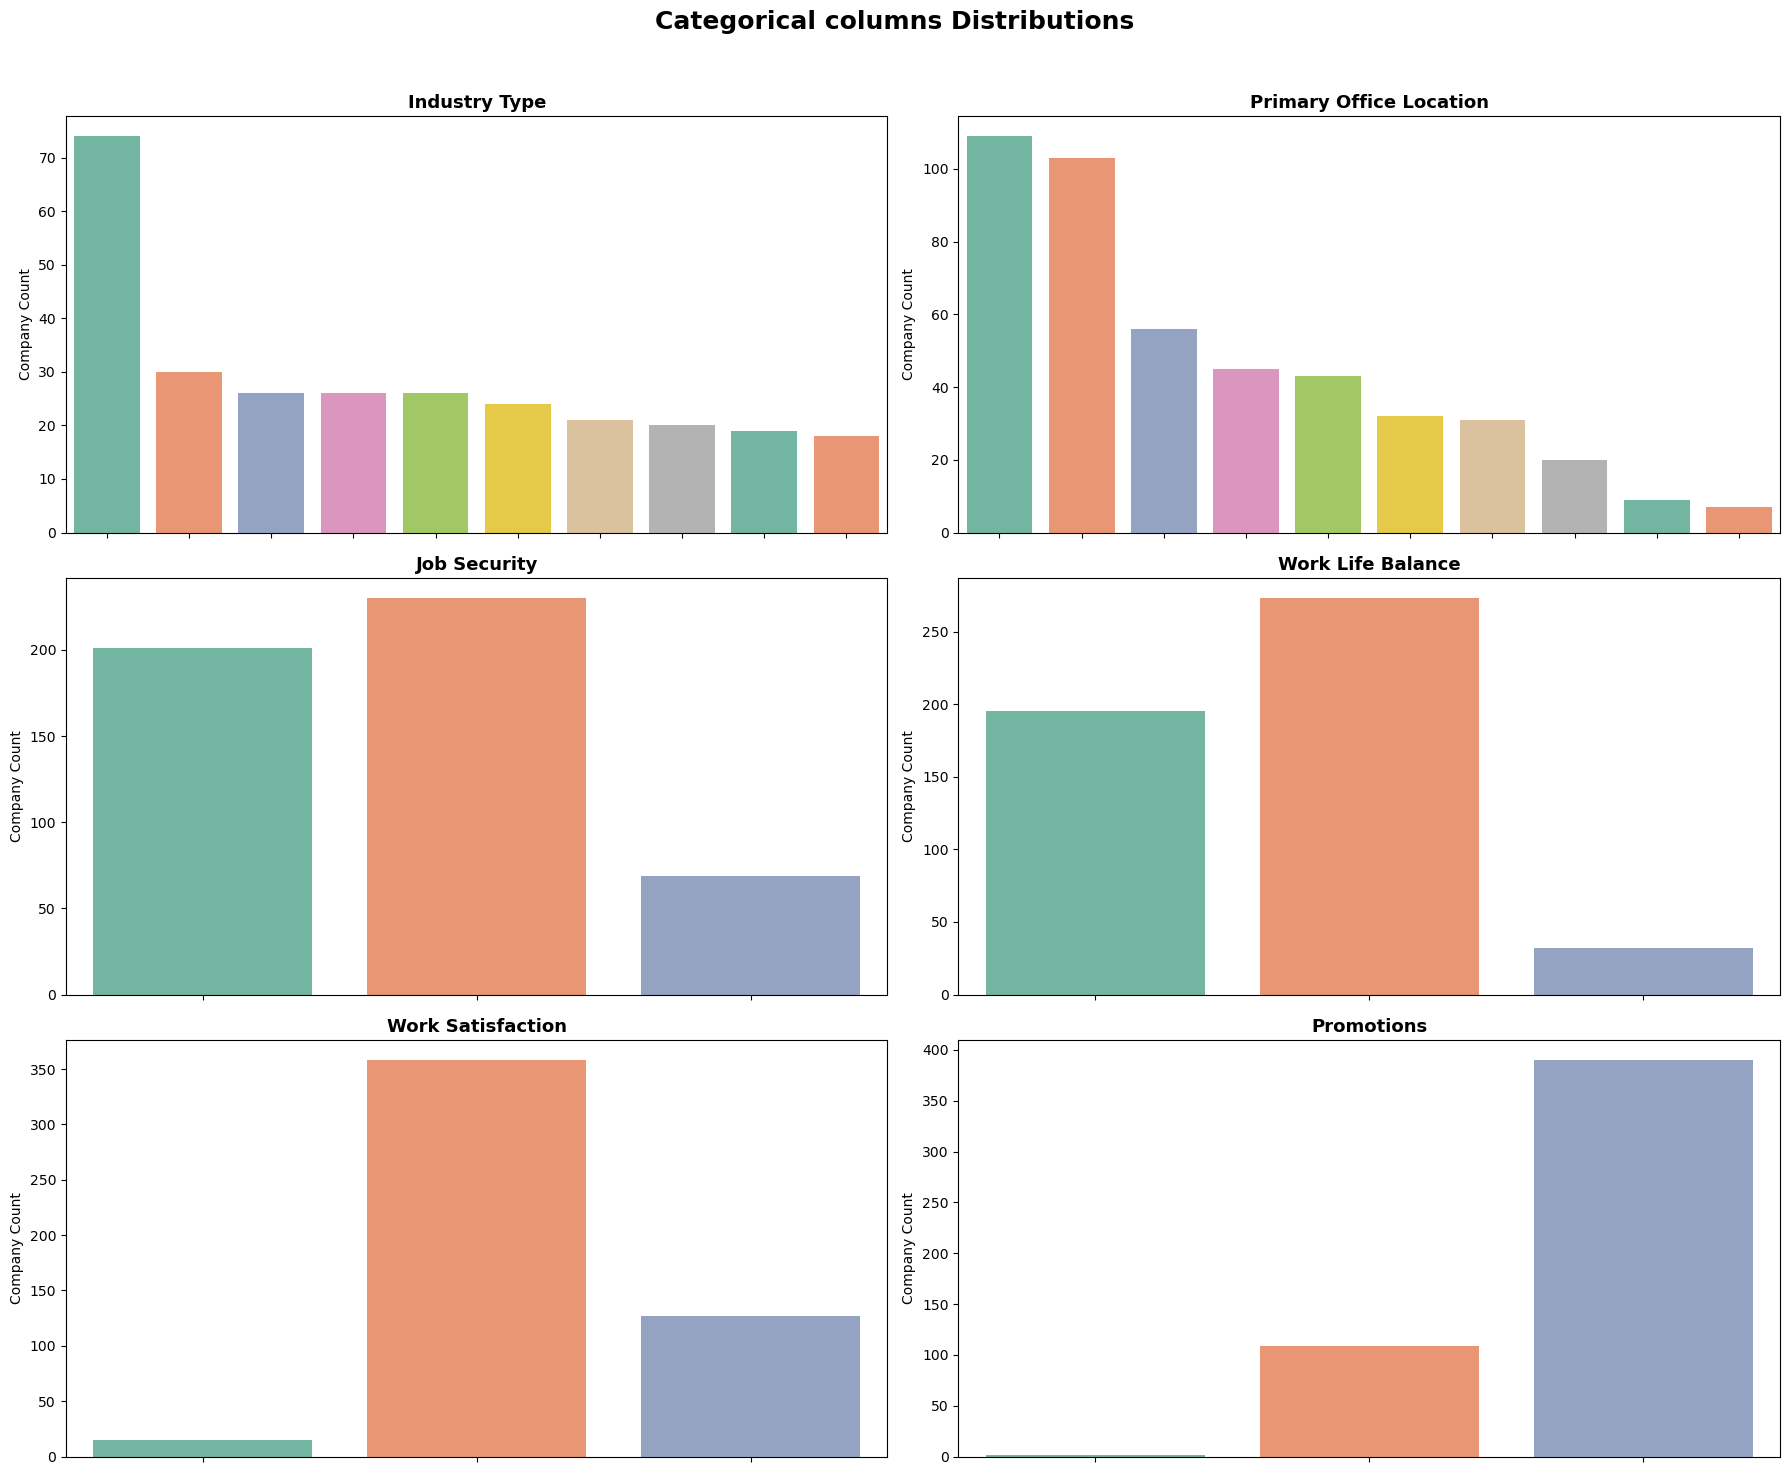

In [42]:
# categorical columns
cat_cols = ['Industry Type','Primary Office Location','Job Security','Work Life Balance','Work Satisfaction','Promotions']
ordinal_order = ['High', 'Medium', 'Low']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]

    if col in ['Industry Type', 'Primary Office Location']:
        
        top_values = ambition[col].value_counts().nlargest(10).index
        plot_data = ambition[ambition[col].isin(top_values)]
        order = top_values
    else:
        plot_data = ambition
        order = ordinal_order  

    sns.countplot(data=plot_data, x=col, order=order, palette='Set2', ax=ax)
    
    ax.set_title(f"{col}", fontsize=13, weight='bold')
    ax.set_ylabel("Company Count")
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Categorical columns Distributions", fontsize=18, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


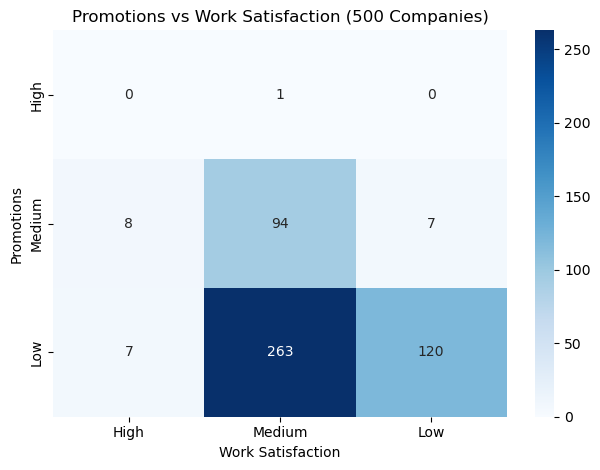

In [43]:
# improve job/work satisfaction

sns.heatmap(pd.crosstab(ambition['Promotions'], ambition['Work Satisfaction'])
            .reindex(index=['High', 'Medium', 'Low'], columns=['High', 'Medium', 'Low']),
            annot=True, fmt='d', cmap='Blues')
plt.title("Promotions vs Work Satisfaction (500 Companies)")
plt.tight_layout()
plt.show()

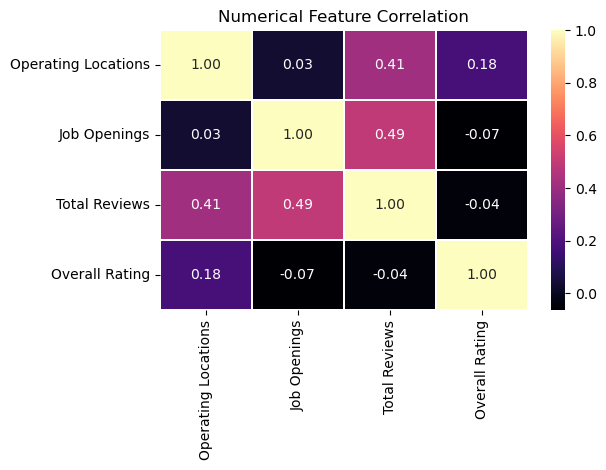

In [44]:
corr = ambition[['Operating Locations', 'Job Openings', 'Total Reviews', 'Overall Rating']].corr()

sns.heatmap(corr, annot=True, cmap='magma', fmt=".2f", linewidths=0.3)
plt.title('Numerical Feature Correlation')
plt.tight_layout()
plt.show()

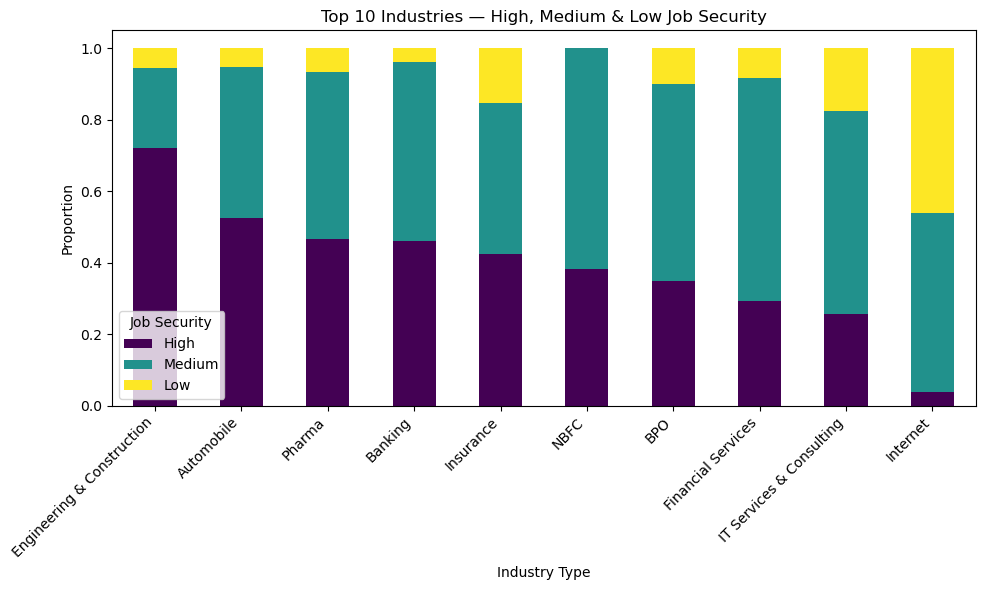

In [45]:
## Top 10 industries by company count with High, Medium and Low Job Security

#top 10 industries by company count
top10 = ambition['Industry Type'].value_counts().head(10).index

# cross-tab with proportion of High and Low job security
job_sec = pd.crosstab(ambition['Industry Type'],ambition['Job Security'],normalize='index')[['High','Medium', 'Low']]

# Filter only for top 10 industries
job_sec_top10 = job_sec.loc[top10]

# Sort industries by proportion of High job security
job_sec_top10_sorted = job_sec_top10.sort_values(by='High', ascending=False)

# Plot
job_sec_top10_sorted.plot(
    kind='bar',
    stacked=True,
    colormap='viridis',
    figsize=(10,6))

plt.title('Top 10 Industries — High, Medium & Low Job Security')
plt.ylabel('Proportion')
plt.xlabel('Industry Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [46]:
# top 10 industries by company count
job_sec_top10_sorted

Job Security,High,Medium,Low
Industry Type,,,
Engineering & Construction,0.722222,0.222222,0.055556
Automobile,0.526316,0.421053,0.052632
Pharma,0.466667,0.466667,0.066667
Banking,0.461538,0.500000,0.038462
Insurance,0.423077,0.423077,0.153846
NBFC,0.380952,0.619048,0.000000
BPO,0.350000,0.550000,0.100000
Financial Services,0.291667,0.625000,0.083333
IT Services & Consulting,0.256757,0.567568,0.175676


In [47]:
ambition.head()

,Company Name,Industry Type,Primary Office Location,Operating Locations,Job Openings,Total Reviews,Overall Rating,Job Security,Work Life Balance,Work Satisfaction,Promotions
0,TCS,IT Services & Consulting,Bangalore,433,685,1,3.4,High,Medium,Low,Low
1,Accenture,IT Services & Consulting,Bangalore,246,22700,68100,3.7,Medium,Medium,Low,Low
2,Wipro,IT Services & Consulting,Hyderabad,368,4600,61000,3.7,High,Medium,Low,Low
3,Cognizant,IT Services & Consulting,Hyderabad,226,583,57900,3.7,Medium,Medium,Low,Low
4,Capgemini,IT Services & Consulting,Bangalore,181,1700,49600,3.7,High,High,Low,Low


C:\Users\sripa\AppData\Local\Temp\ipykernel_21880\1522845519.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_openings, y="Company Name", x="Job Openings", palette="crest")


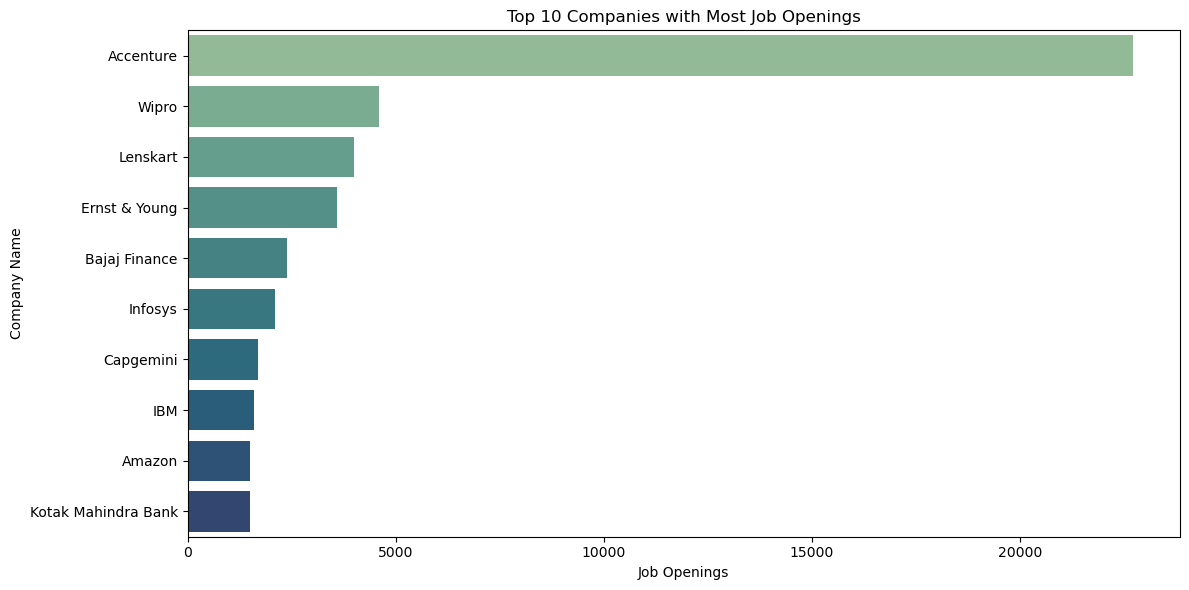

In [48]:
#10 companies with high job opening
top10_openings = ambition[["Company Name", "Job Openings"]].sort_values(by="Job Openings", ascending=False).head(10)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(data=top10_openings, y="Company Name", x="Job Openings", palette="crest")
plt.title("Top 10 Companies with Most Job Openings")
plt.xlabel("Job Openings")
plt.ylabel("Company Name")
plt.tight_layout()
plt.show()

C:\Users\sripa\AppData\Local\Temp\ipykernel_21880\2324398590.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top10_industries, y="Industry Type", x="Job Openings", palette="flare")


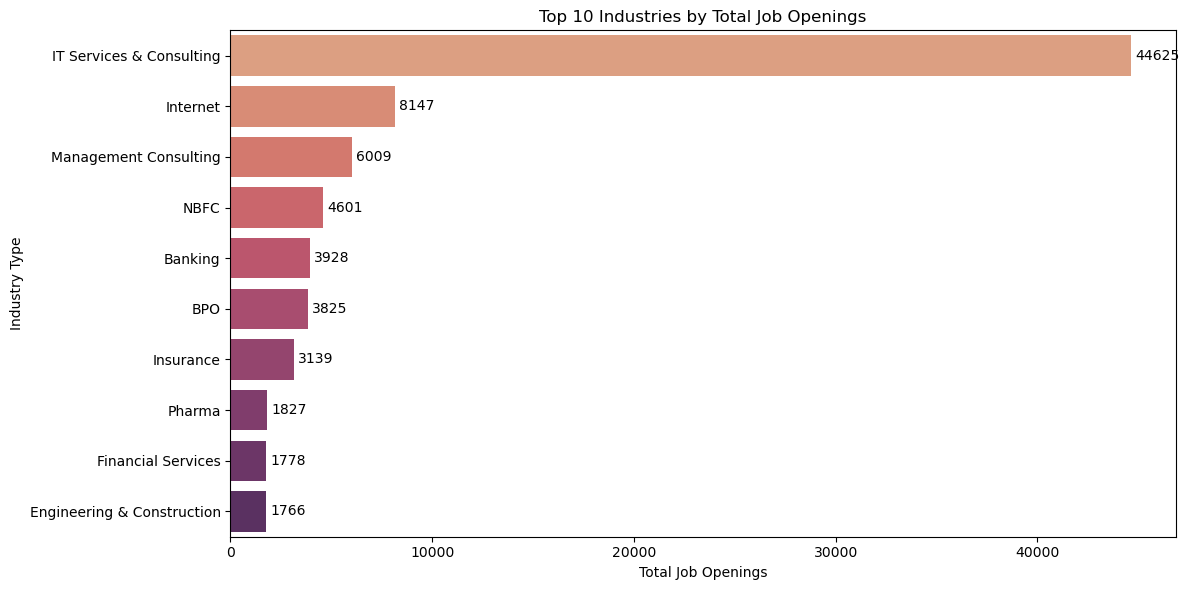

In [49]:
# Group by industry and sort by total job openings top 10
ambition = pd.read_csv("ambitionbox_companies.csv")
top10_industries = (
    ambition.groupby("Industry Type")["Job Openings"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Plot
plt.figure(figsize=(12,6))
ax = sns.barplot(data=top10_industries, y="Industry Type", x="Job Openings", palette="flare")

# Add value labels on bars
for i in ax.containers:
    ax.bar_label(i, fmt='%.0f', label_type='edge', padding=3)

plt.title("Top 10 Industries by Total Job Openings")
plt.xlabel("Total Job Openings")
plt.ylabel("Industry Type")
plt.tight_layout()
plt.show()

C:\Users\sripa\AppData\Local\Temp\ipykernel_21880\496096043.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=top10_companies, y="Company Name", x="Overall Rating", palette="flare")


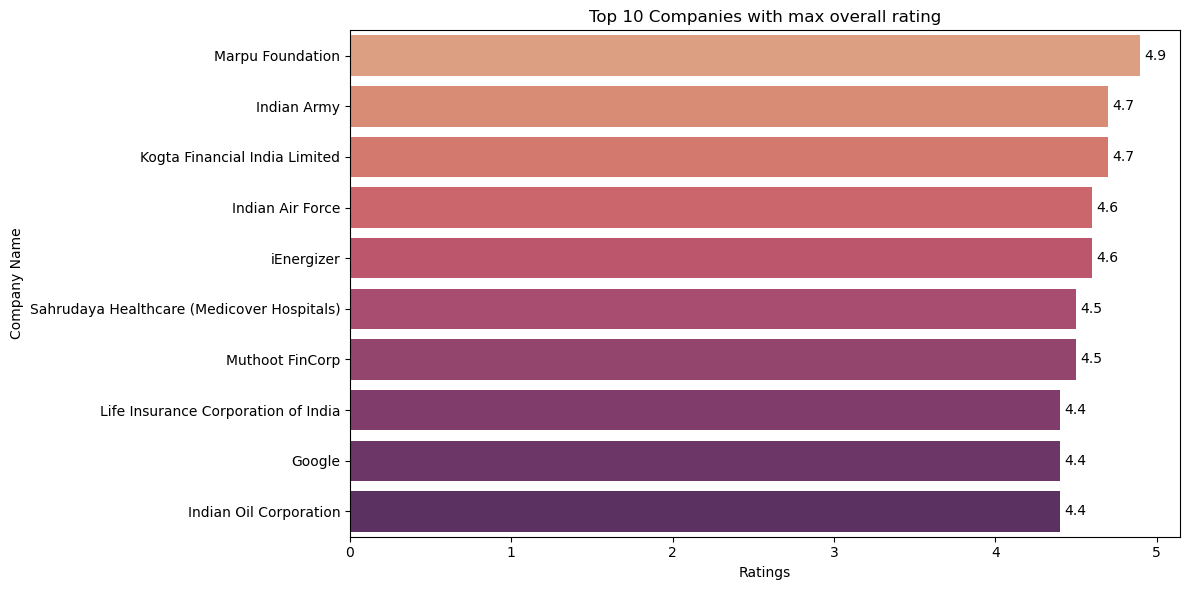

In [50]:
### Top 10 Companies with max overall rating
top10_companies=ambition.groupby("Company Name")["Overall Rating"].max().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12,6))
ax1 = sns.barplot(data=top10_companies, y="Company Name", x="Overall Rating", palette="flare")
for container in ax1.containers:
    labels = [f"{bar.get_width():.1f}" for bar in container]
    ax1.bar_label(container, labels=labels, label_type="edge", padding=3)

plt.title("Top 10 Companies with max overall rating")
plt.xlabel("Ratings")
plt.ylabel("Company Name")
plt.tight_layout()
plt.show()

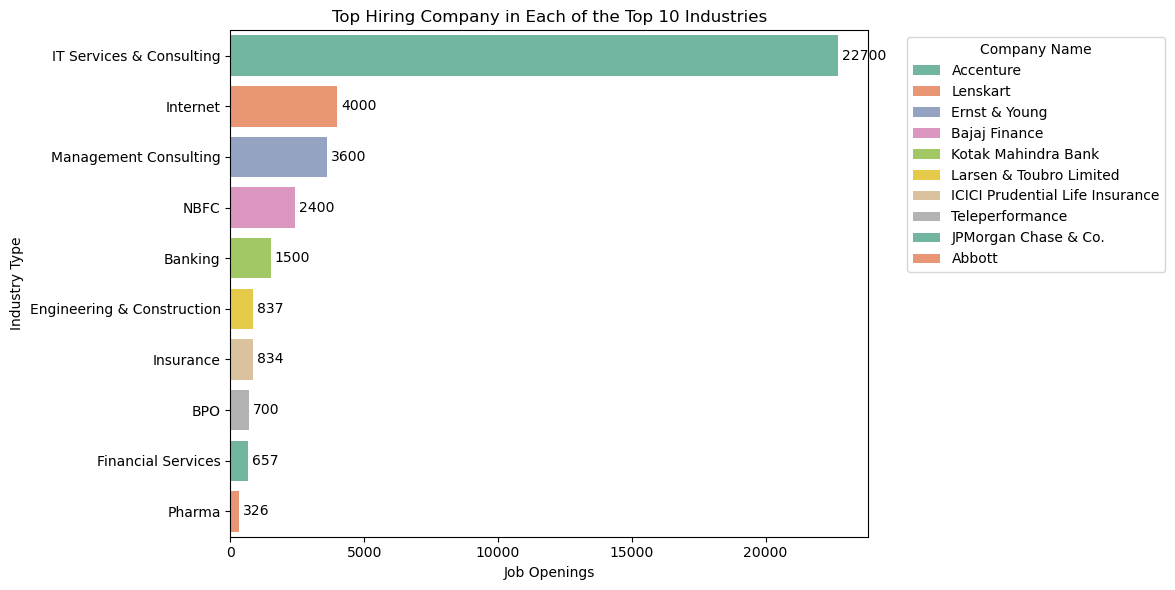

In [51]:
# top 10 industries by total job openings
top10_industries = (ambition.groupby("Industry Type", observed=True)["Job Openings"].sum().sort_values(ascending=False).head(10).index)

filtered_df = ambition[ambition["Industry Type"].isin(top10_industries)]

top_companies_in_industries = (
    filtered_df.loc[
        filtered_df.groupby("Industry Type", observed=True)["Job Openings"].idxmax()]
    .sort_values("Job Openings", ascending=False))

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_companies_in_industries,y="Industry Type",x="Job Openings",hue="Company Name",dodge=False,palette="Set2")

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', padding=3)

plt.title("Top Hiring Company in Each of the Top 10 Industries")
plt.xlabel("Job Openings")
plt.ylabel("Industry Type")
plt.legend(title="Company Name", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


C:\Users\sripa\AppData\Local\Temp\ipykernel_21880\2994090972.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top10_reviews, y="Industry Type", x="Total Reviews", palette="rocket")


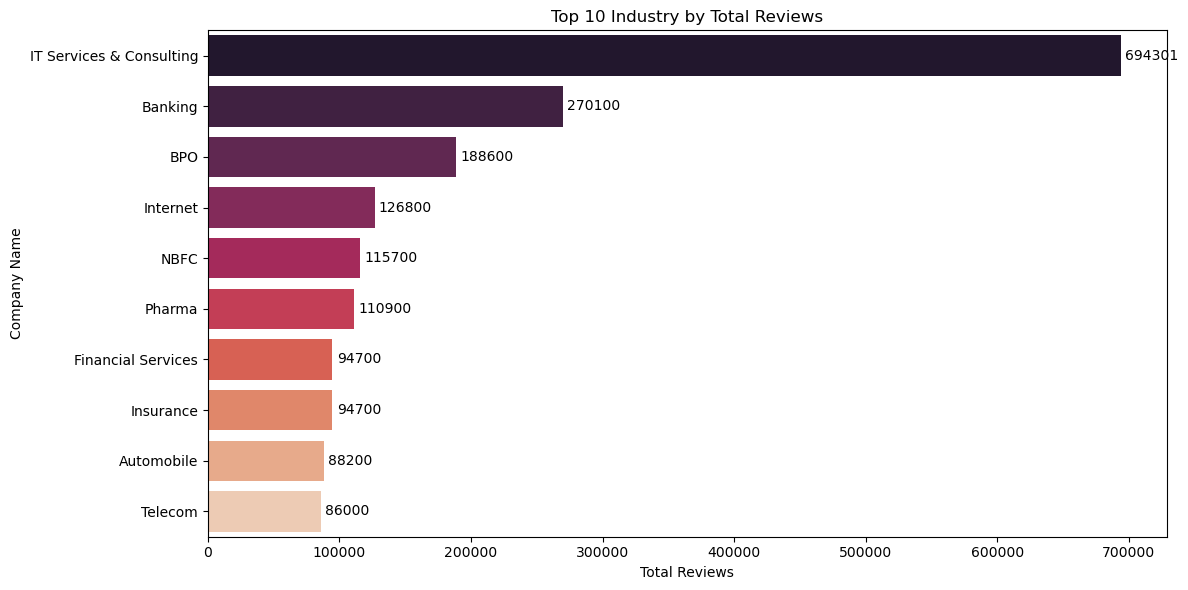

,Industry Type,Total Reviews
0,IT Services & Consulting,694301
1,Banking,270100
2,BPO,188600
3,Internet,126800
4,NBFC,115700
5,Pharma,110900
6,Financial Services,94700
7,Insurance,94700
8,Automobile,88200
9,Telecom,86000


In [52]:
# top 10 companies by total reviews
top10_reviews = (ambition.groupby("Industry Type")["Total Reviews"].sum().sort_values(ascending=False).head(10).reset_index())

# Plot
plt.figure(figsize=(12,6))
ax = sns.barplot(data=top10_reviews, y="Industry Type", x="Total Reviews", palette="rocket")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, label_type="edge")

plt.title("Top 10 Industry by Total Reviews")
plt.xlabel("Total Reviews")
plt.ylabel("Company Name")
plt.tight_layout()
plt.show()
top10_reviews

C:\Users\sripa\AppData\Local\Temp\ipykernel_21880\782259499.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=high_df, x='Industry Type', order=top10, palette='Set2')


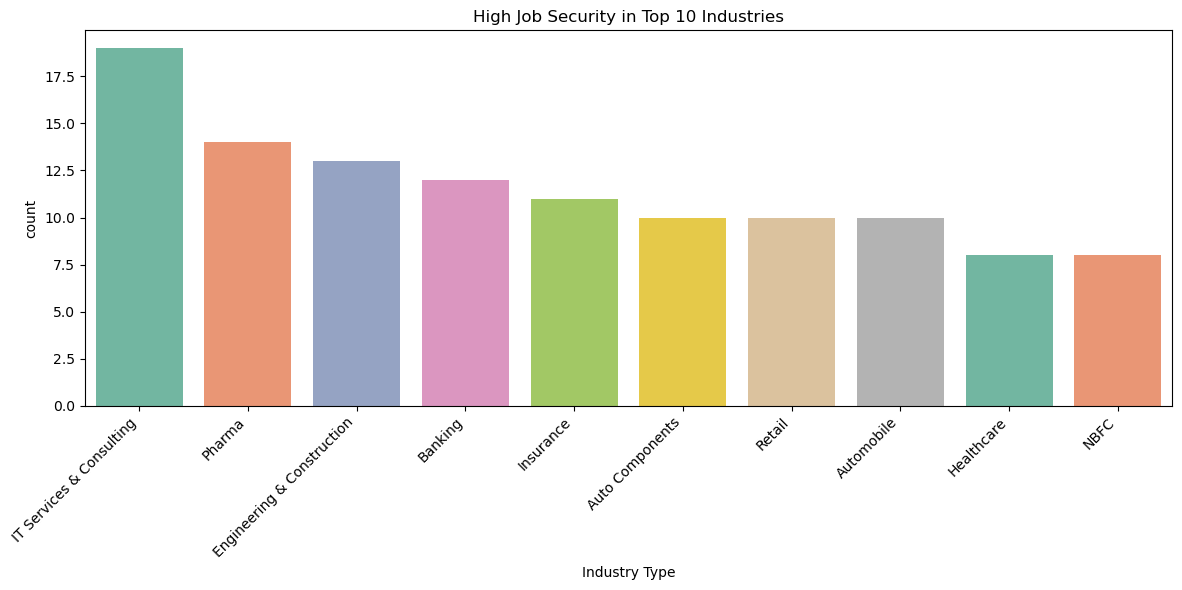

In [53]:
#Filter High Job Security
high_df = ambition[ambition['Job Security'] == 'High']

#top 10 industry types
top10 = high_df['Industry Type'].value_counts().index[:10]

#Plot
plt.figure(figsize=(12, 6))
sns.countplot(data=high_df, x='Industry Type', order=top10, palette='Set2')
plt.title('High Job Security in Top 10 Industries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\sripa\AppData\Local\Temp\ipykernel_21880\354188031.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.index, y=top_locations.values, palette="Set2")


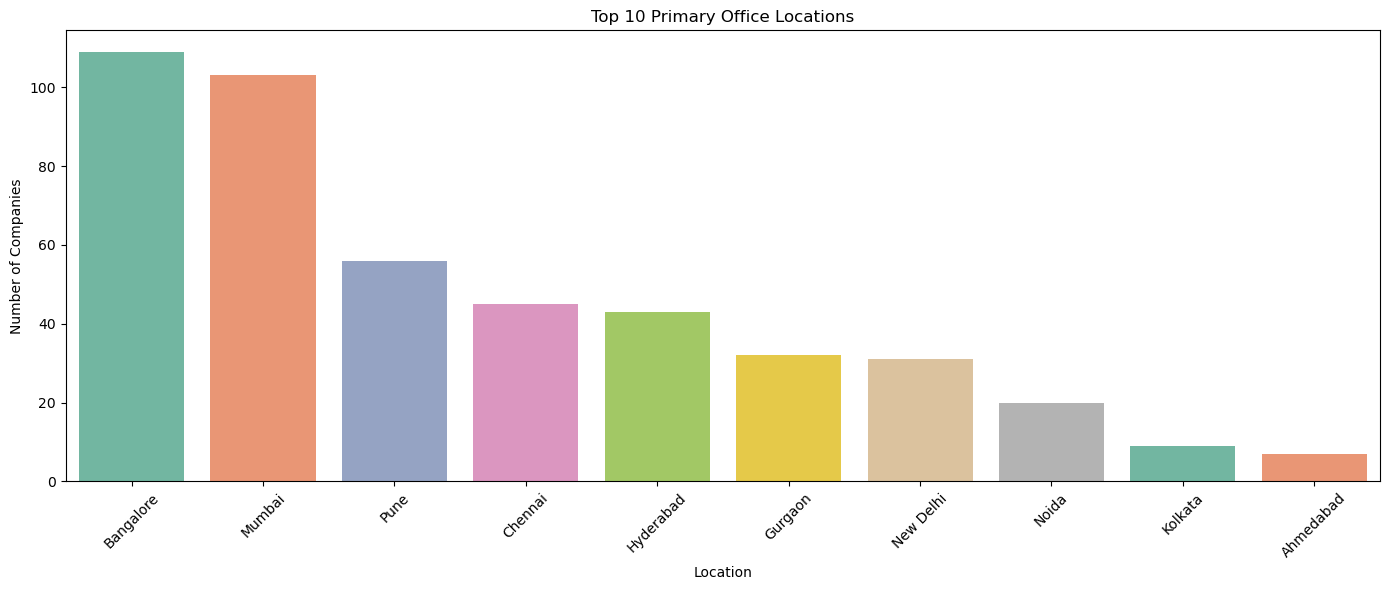

In [56]:
#  top 10 locations
top_locations = ambition['Primary Office Location'].value_counts().head(10)

# Plotting
plt.figure(figsize=(14, 6))
sns.barplot(x=top_locations.index, y=top_locations.values, palette="Set2")
plt.title("Top 10 Primary Office Locations")
plt.xlabel("Location")
plt.ylabel("Number of Companies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\sripa\AppData\Local\Temp\ipykernel_21880\2883365541.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_mapped = df[['Job Security', 'Work Life Balance', 'Work Satisfaction', 'Promotions']].replace(rating_map)
C:\Users\sripa\AppData\Local\Temp\ipykernel_21880\2883365541.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_mapped = df[['Job Security', 'Work Life Balance', 'Work Satisfaction', 'Promotions']].replace(rating_map)
C:\Users\sripa\AppData\Local\Temp\ipykernel_21880\2883365541.py:3: FutureWarning: Downcasting behavior in `re

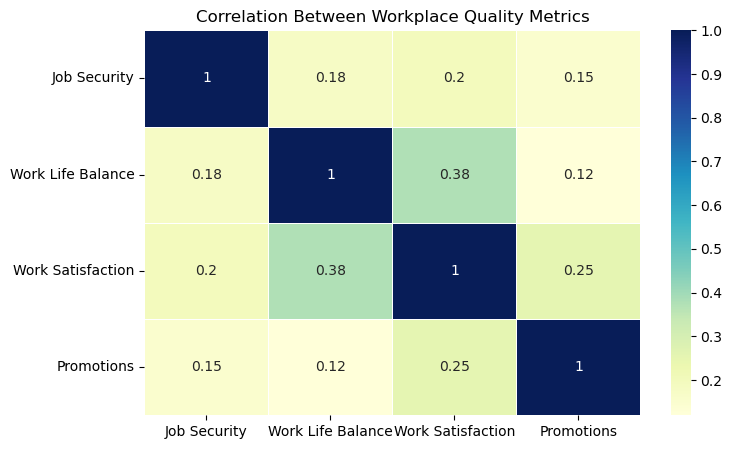

In [54]:
# Map High=3, Medium=2, Low=1
rating_map = {'High': 3, 'Medium': 2, 'Low': 1}
df_mapped = df[['Job Security', 'Work Life Balance', 'Work Satisfaction', 'Promotions']].replace(rating_map)

plt.figure(figsize=(8, 5))
sns.heatmap(df_mapped.corr(), annot=True, cmap="YlGnBu", linewidths=0.5)
plt.title("Correlation Between Workplace Quality Metrics")
plt.show()

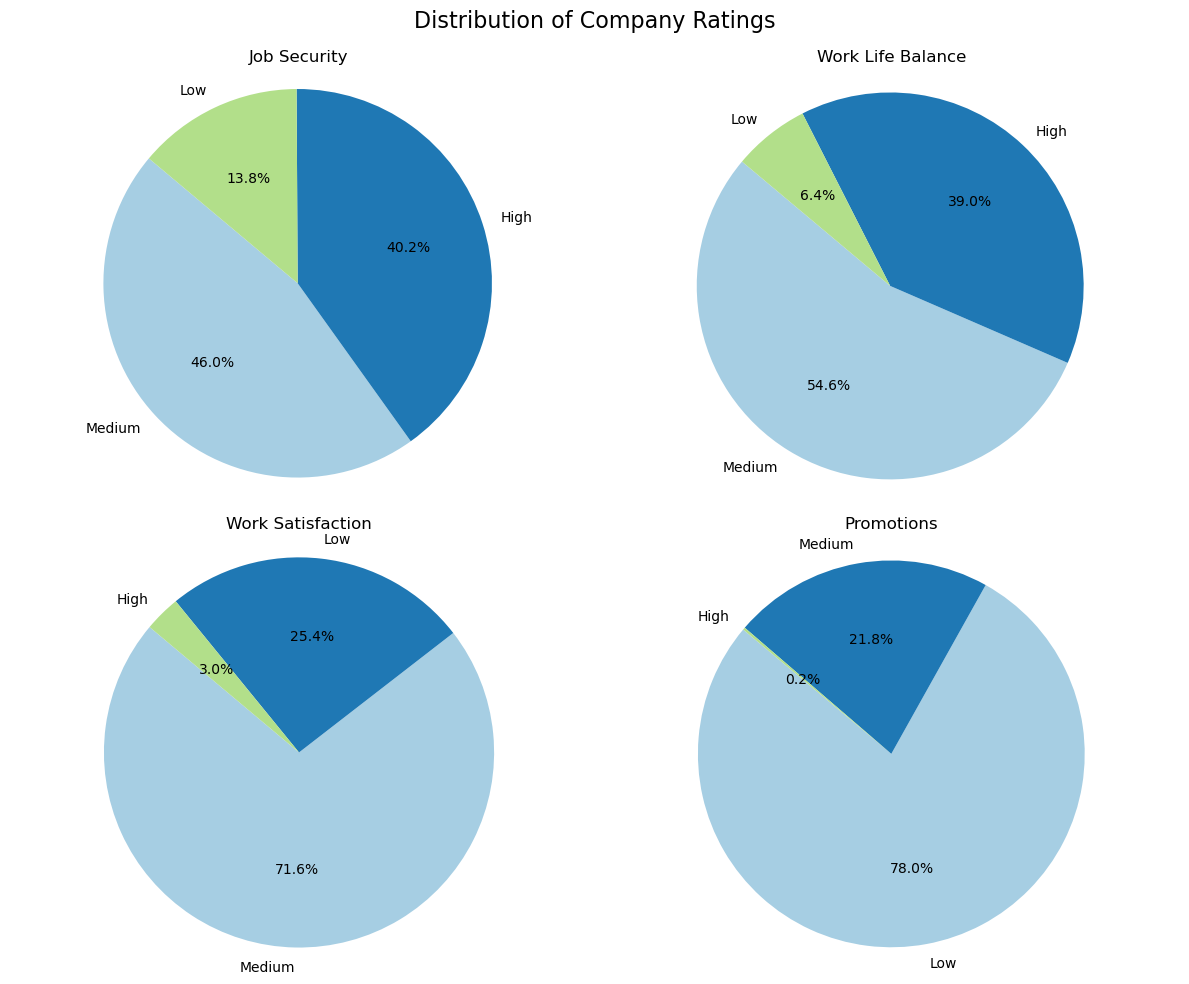

In [55]:
import matplotlib.pyplot as plt

# Categorical columns to visualize
rating_columns = ["Job Security", "Work Life Balance", "Work Satisfaction", "Promotions"]

# Define a clean color palette — replacing purple with navy
custom_colors = ['#a6cee3', '#1f78b4', '#b2df8a']  # soft sky, navy blue, mint green


# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Plot each pie chart
for i, col in enumerate(rating_columns):
    counts = ambition[col].value_counts()
    axes[i].pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=custom_colors[:len(counts)] )
    axes[i].set_title(col)
    axes[i].axis('equal')

plt.suptitle("Distribution of Company Ratings", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()